# PIER vs single-model explanations under two scenarios (multi-seed, with CIs)

This notebook compares **peer-relative explanations (PIER / DISCO)** with **single-model explanations**
(ICE, PDP, SHAP) under two synthetic scenarios, across multiple random seeds:

1. **Common-pattern scenario**: target and peers are trained on the *same* features.  
   - Along the chosen intervention path, the target's behaviour can be expressed by the peers.  
   - We expect PIER to be close to zero, while ICE / PDP / SHAP are large.

2. **Target-blind scenario**: the target is trained **blind to the intervention feature** (its input column is zeroed at training time), while peers still use all features.  
   - Along the same intervention path, peers move strongly but the target barely reacts.  
   - Single-model explanations (ICE / PDP / SHAP) are close to zero, but PIER has a large absolute value.

For both scenarios we:
- Run experiments over **10 random seeds**,  
- Aggregate the per-seed curves, and  
- Plot **mean curves with 95% confidence intervals** (per-dose) for PIER, and mean curves for ICE / PDP / SHAP.


In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [15]:
def ensure_2d(x):
    """Ensure input is 2D (n_samples, n_features)."""
    x = np.asarray(x)
    if x.ndim == 1:
        x = x[None, :]
    return x

def predict_scalar(predict_fn, X, g=None):
    """
    Apply predict_fn and an optional scalarization g, return 1D array.
    For regression we simply use identity (g=None).
    """
    raw = predict_fn(X)
    if g is not None:
        raw = g(raw)
    return np.asarray(raw).reshape(-1)

def apply_Td(X, theta, intervention):
    """
    Apply the intervention T_d at dose theta.
    We support:
    - an object with .apply(X, theta)
    - a callable intervention(X, theta)
    """
    if hasattr(intervention, "apply"):
        return intervention.apply(X, theta)
    return intervention(X, theta)


In [16]:
class AdditiveShift:
    """
    Simple additive shift intervention on one feature:
    x[:, feature_idx] += theta, with optional clipping to [clip_min, clip_max].
    """
    def __init__(self, feature_idx, clip_min=None, clip_max=None):
        self.feature_idx = int(feature_idx)
        self.clip_min = clip_min
        self.clip_max = clip_max

    def apply(self, X, theta):
        X = np.asarray(X)
        X_new = np.array(X, copy=True)
        k = self.feature_idx
        X_new[:, k] = X_new[:, k] + theta
        if self.clip_min is not None:
            X_new[:, k] = np.maximum(X_new[:, k], self.clip_min)
        if self.clip_max is not None:
            X_new[:, k] = np.minimum(X_new[:, k], self.clip_max)
        return X_new


In [17]:
class SklearnDeviceWrapper:
    """
    Minimal wrapper for sklearn regressors to provide
    .predict_raw / .predict interfaces similar to Device classes.
    """
    def __init__(self, estimator, name, scalarize=None):
        self.estimator = estimator
        self.name = name
        self.scalarize = scalarize  # optional g(·)

    def predict(self, X):
        y = self.estimator.predict(X)
        if self.scalarize is not None:
            y = self.scalarize(y)
        return y

    def predict_raw(self, X):
        # Some code paths may call predict_raw; here it is identical to predict.
        return self.predict(X)

def make_device(estimator, name, scalarize=None):
    """Factory for device objects; can be swapped for repository-specific Device classes."""
    return SklearnDeviceWrapper(estimator=estimator, name=name, scalarize=scalarize)

def get_predict_fn(device):
    """Return a callable prediction function from a Device-like object."""
    if hasattr(device, "predict_raw") and callable(getattr(device, "predict_raw")):
        return device.predict_raw
    return device.predict


In [18]:
def response_on_grid(predict_fn, X, thetas, intervention, g=None):
    """
    Evaluate predict_fn on X under all doses in thetas using the given intervention.
    Returns array of shape (n_samples, n_thetas).
    """
    X = np.asarray(X)
    thetas = np.asarray(list(thetas))
    out = []
    for th in thetas:
        X_th = apply_Td(X, th, intervention)
        out.append(predict_scalar(predict_fn, X_th, g))
    return np.stack(out, axis=1)  # (n_samples, n_thetas)


def select_anchors_response_space(target_device, probes_X, x_query, pre_thetas, intervention,
                                  num_anchors=12, tau=0.5, g=None, rng=None):
    """
    Select anchors in response space using KNN on pre-window trajectories.
    Returns:
        anchor_idx: indices of selected probes
        anchor_weights: normalized kernel weights over selected probes
        Ft_anchors: target responses on anchors (pre-window)
        Ft_query: target responses at query (pre-window)
    """
    if rng is None:
        rng = np.random.default_rng()

    predict_t = get_predict_fn(target_device)
    Ft_probes = response_on_grid(predict_t, probes_X, pre_thetas, intervention, g)  # (m, q)
    Ft_query = response_on_grid(predict_t, ensure_2d(x_query), pre_thetas, intervention, g)  # (1, q)

    dists = np.linalg.norm(Ft_probes - Ft_query[0], axis=1)
    anchor_idx = np.argsort(dists)[:num_anchors]
    selected_dists = dists[anchor_idx]

    scale = np.median(selected_dists) + 1e-9
    if scale <= 0:
        scale = np.mean(selected_dists) + 1e-9
    kernel = np.exp(-(selected_dists / scale) ** 2 / (2 * tau ** 2))
    if kernel.sum() <= 0:
        kernel = np.ones_like(kernel)
    anchor_weights = kernel / kernel.sum()

    return anchor_idx, anchor_weights, Ft_probes[anchor_idx], Ft_query


In [19]:
def project_to_simplex(v):
    """
    Project vector v onto the probability simplex {w >= 0, sum w = 1}.
    Implementation follows Duchi et al. (2008).
    """
    v = np.asarray(v, dtype=float)
    if v.sum() == 1.0 and np.all(v >= 0.0):
        return v
    n = v.size
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u + (1 - cssv) / (np.arange(n) + 1) > 0)[0]
    if len(rho) == 0:
        return np.ones_like(v) / n
    rho = rho[-1]
    theta = (cssv[rho] - 1) / float(rho + 1)
    w = np.maximum(v - theta, 0)
    return w


def solve_simplex_ridge(X, y, lam=1e-2, num_iters=2000, step_size=None):
    """
    Solve: min_w 0.5||Xw - y||^2 + 0.5*lam||w||^2 s.t. w >= 0, 1^T w = 1
    using projected gradient descent onto the simplex.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    n = X.shape[1]
    w = np.ones(n) / n

    if step_size is None:
        L = np.linalg.norm(X, 2) ** 2 + lam
        step_size = 1.0 / (L + 1e-9)

    for _ in range(num_iters):
        grad = X.T @ (X @ w - y) + lam * w
        w = project_to_simplex(w - step_size * grad)

    return w


In [20]:
def compute_pier_curve(
    target_device,
    peer_devices,
    probes_X,
    x_query,
    pre_thetas,
    eval_thetas,
    intervention,
    num_anchors=12,
    tau=0.5,
    lam=1e-2,
    g=None,
    rng=None,
):
    """
    Compute PIER curve for a single query x_query using DISCO-style pipeline.
    """
    if rng is None:
        rng = np.random.default_rng()

    probes_X = np.asarray(probes_X)
    x_query = ensure_2d(x_query)
    pre_thetas = np.asarray(list(pre_thetas))
    eval_thetas = np.asarray(list(eval_thetas))

    anchor_idx, anchor_weights, Ft_anchors, Ft_query = select_anchors_response_space(
        target_device,
        probes_X,
        x_query,
        pre_thetas,
        intervention,
        num_anchors=num_anchors,
        tau=tau,
        g=g,
        rng=rng,
    )

    y_vec = Ft_anchors.reshape(-1)
    X_cols = []
    for peer in peer_devices:
        predict_peer = get_predict_fn(peer)
        Fj_anchors = response_on_grid(
            predict_peer, probes_X[anchor_idx], pre_thetas, intervention, g
        )
        X_cols.append(Fj_anchors.reshape(-1))
    X_mat = np.stack(X_cols, axis=1)

    weights = solve_simplex_ridge(X_mat, y_vec, lam=lam)

    predict_t = get_predict_fn(target_device)
    y_target_eval = response_on_grid(
        predict_t, x_query, eval_thetas, intervention, g
    )[0]

    peer_eval_mat = []
    for peer in peer_devices:
        predict_peer = get_predict_fn(peer)
        peer_eval_mat.append(
            response_on_grid(
                predict_peer, x_query, eval_thetas, intervention, g
            )[0]
        )
    peer_eval_mat = np.stack(peer_eval_mat, axis=0)
    y_peer_eval = weights @ peer_eval_mat

    pier = y_target_eval - y_peer_eval

    dtheta = np.diff(np.r_[eval_thetas[0], eval_thetas])
    auc_abs = float(np.sum(np.abs(pier) * dtheta))

    return {
        "theta": eval_thetas,
        "pier": pier,
        "y_target": y_target_eval,
        "y_peer": y_peer_eval,
        "weights": weights,
        "anchor_idx": anchor_idx,
        "anchor_weights": anchor_weights,
        "auc_abs": auc_abs,
    }


In [21]:
def ice_curve(predict_fn, x_query, thetas, intervention, g=None, return_delta=True):
    """
    ICE: single-instance response curve along the intervention path.
    If return_delta=True, subtract the baseline at the first theta.
    """
    x_query = ensure_2d(x_query)
    thetas = np.asarray(list(thetas))
    values = []
    for th in thetas:
        x_th = apply_Td(x_query, th, intervention)
        values.append(predict_scalar(predict_fn, x_th, g)[0])
    values = np.asarray(values)
    if return_delta:
        values = values - values[0]
    return thetas, values


def pdp_curve(predict_fn, X_bg, thetas, intervention, g=None, return_delta=True, batch_size=2048):
    """
    PDP: average response curve over a background sample X_bg.
    If return_delta=True, subtract the baseline mean at theta "no intervention".
    """
    X_bg = np.asarray(X_bg)
    thetas = np.asarray(list(thetas))

    def mean_pred(X):
        vals = []
        for i in range(0, len(X), batch_size):
            vals.append(predict_scalar(predict_fn, X[i : i + batch_size], g))
        return float(np.mean(np.concatenate(vals)))

    base_mean = mean_pred(X_bg)
    values = []
    for th in thetas:
        X_th = apply_Td(X_bg, th, intervention)
        values.append(mean_pred(X_th))
    values = np.asarray(values)
    if return_delta:
        values = values - base_mean
    return thetas, values


def shap_path_curve(predict_fn, X_bg, x_query, thetas, intervention, feature_idx,
                    g=None, max_bg=512, explainer_kwargs=None):
    """
    SHAP-path: for each dose theta, compute SHAP values at T_d(theta, x_query)
    and extract the contribution of feature_idx.
    """
    import shap

    if explainer_kwargs is None:
        explainer_kwargs = {}

    X_bg = np.asarray(X_bg)
    rng = np.random.default_rng(2024)
    if len(X_bg) > max_bg:
        sel_idx = rng.choice(len(X_bg), size=max_bg, replace=False)
        X_bg_ref = X_bg[sel_idx]
    else:
        X_bg_ref = X_bg

    def pred_scalar(X):
        return predict_scalar(predict_fn, X, g)

    explainer = shap.Explainer(pred_scalar, X_bg_ref, **explainer_kwargs)

    x_query = ensure_2d(x_query)
    thetas = np.asarray(list(thetas))
    shap_vals = []
    for th in thetas:
        x_th = apply_Td(x_query, th, intervention)
        exp = explainer(x_th)
        vals = np.array(exp.values).reshape(1, -1)[0]
        shap_vals.append(float(vals[feature_idx]))
    return thetas, np.asarray(shap_vals)


In [22]:
def mean_and_ci(y_values, alpha=0.05):
    """
    Compute mean and (1-alpha) confidence interval across seeds for each theta.
    y_values: array of shape (n_seeds, n_thetas)
    Uses a t-interval with df = n_seeds - 1.
    For n_seeds=10 we use t_0.975,9 ≈ 2.262.
    """
    y_values = np.asarray(y_values)
    mean = y_values.mean(axis=0)
    std = y_values.std(axis=0, ddof=1)
    n = y_values.shape[0]
    if n == 10:
        tcrit = 2.262
    else:
        tcrit = 1.96
    half_width = tcrit * std / np.sqrt(n)
    lower = mean - half_width
    upper = mean + half_width
    return mean, lower, upper


In [23]:
def build_fixed_dataset(seed):
    """Build a single synthetic regression dataset with a fixed seed."""
    X, y = make_regression(
        n_samples=8000,
        n_features=16,
        n_informative=8,
        noise=10.0,
        random_state=seed,
    )
    X_tr, X_rest, y_tr, y_rest = train_test_split(
        X, y, test_size=0.4, random_state=seed
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_rest, y_rest, test_size=0.5, random_state=seed
    )
    return X_tr, y_tr, X_val, y_val, X_te, y_te


def choose_intervention_feature(seed_for_k=123):
    """
    Train a reference GBRT on a fixed dataset and pick the most important feature
    as the intervention dimension k.
    """
    X_tr_fixed, y_tr_fixed, X_val_fixed, y_val_fixed, X_te_fixed, y_te_fixed = build_fixed_dataset(DATA_SEED)

    ref_model = GradientBoostingRegressor(
        random_state=999, n_estimators=300, max_depth=3
    ).fit(X_tr_fixed, y_tr_fixed)
    importances = ref_model.feature_importances_
    k = int(np.argmax(importances))
    return k, X_tr_fixed, y_tr_fixed, X_val_fixed, y_val_fixed, X_te_fixed, y_te_fixed


In [24]:
def run_scenario_common_fixed_data(
    seed,
    feature_idx,
    theta0,
    theta_eval,
    intervention,
    X_tr,
    y_tr,
    X_val,
    X_te,
    g=None,
):
    """
    Scenario 1 (Common-pattern) on a fixed dataset:
    target and peers are all trained on full features.
    """
    probes_X = X_val
    rng = np.random.default_rng(seed)
    x_query = X_te[rng.integers(0, len(X_te))]

    # Train target and peers on the SAME X_tr, only random_state changes
    target_model = GradientBoostingRegressor(
        random_state=seed, n_estimators=300, max_depth=3
    ).fit(X_tr, y_tr)
    peer_model_1 = RandomForestRegressor(
        n_estimators=200, max_depth=3, random_state=seed + 1
    ).fit(X_tr, y_tr)
    peer_model_2 = Ridge(alpha=1.0).fit(X_tr, y_tr)
    peer_model_3 = GradientBoostingRegressor(
        random_state=seed + 2, n_estimators=150, max_depth=2
    ).fit(X_tr, y_tr)

    target_device = make_device(target_model, f"common_target_seed{seed}", scalarize=g)
    peer_devices = [
        make_device(peer_model_1, f"common_peer1_seed{seed}", scalarize=g),
        make_device(peer_model_2, f"common_peer2_seed{seed}", scalarize=g),
        make_device(peer_model_3, f"common_peer3_seed{seed}", scalarize=g),
    ]

    pier_res = compute_pier_curve(
        target_device=target_device,
        peer_devices=peer_devices,
        probes_X=probes_X,
        x_query=x_query,
        pre_thetas=theta0,
        eval_thetas=theta_eval,
        intervention=intervention,
        num_anchors=12,
        tau=0.5,
        lam=1e-2,
        g=g,
        rng=rng,
    )

    predict_target = get_predict_fn(target_device)
    θ, ice_vals = ice_curve(predict_target, x_query, theta_eval, intervention, g=g, return_delta=True)
    _, pdp_vals = pdp_curve(predict_target, probes_X, theta_eval, intervention, g=g, return_delta=True)
    _, shap_vals = shap_path_curve(predict_target, probes_X, x_query, theta_eval,
                                   intervention, feature_idx=feature_idx, g=g)

    assert np.allclose(pier_res["theta"], θ)

    return {
        "theta": θ,
        "pier":  pier_res["pier"],
        "ice":   ice_vals,
        "pdp":   pdp_vals,
        "shap":  shap_vals,
        "auc_pier_abs": pier_res["auc_abs"],
    }


In [25]:
def run_scenario_target_blind_fixed_data(
    seed,
    feature_idx,
    theta0,
    theta_eval,
    intervention,
    X_tr,
    y_tr,
    X_val,
    X_te,
    g=None,
):
    """
    Scenario 2 (Target-blind) on a fixed dataset:
    target does NOT see feature_idx at training time,
    while peers are trained on full features.
    """
    probes_X = X_val
    rng = np.random.default_rng(seed)
    x_query = X_te[rng.integers(0, len(X_te))]

    # Peers on full X_tr
    peer_model_1 = RandomForestRegressor(
        n_estimators=200, max_depth=3, random_state=seed + 10
    ).fit(X_tr, y_tr)
    peer_model_2 = Ridge(alpha=1.0).fit(X_tr, y_tr)
    peer_model_3 = GradientBoostingRegressor(
        random_state=seed + 11, n_estimators=150, max_depth=2
    ).fit(X_tr, y_tr)

    # Target blind to feature_idx
    X_tr_blind = X_tr.copy()
    X_tr_blind[:, feature_idx] = 0.0
    target_model_blind = GradientBoostingRegressor(
        random_state=seed + 20, n_estimators=300, max_depth=3
    ).fit(X_tr_blind, y_tr)

    target_device = make_device(target_model_blind, f"blind_target_seed{seed}", scalarize=g)
    peer_devices = [
        make_device(peer_model_1, f"blind_peer1_seed{seed}", scalarize=g),
        make_device(peer_model_2, f"blind_peer2_seed{seed}", scalarize=g),
        make_device(peer_model_3, f"blind_peer3_seed{seed}", scalarize=g),
    ]

    pier_res = compute_pier_curve(
        target_device=target_device,
        peer_devices=peer_devices,
        probes_X=probes_X,
        x_query=x_query,
        pre_thetas=theta0,
        eval_thetas=theta_eval,
        intervention=intervention,
        num_anchors=12,
        tau=0.5,
        lam=1e-2,
        g=g,
        rng=rng,
    )

    predict_target = get_predict_fn(target_device)
    θ, ice_vals = ice_curve(predict_target, x_query, theta_eval, intervention, g=g, return_delta=True)
    _, pdp_vals = pdp_curve(predict_target, probes_X, theta_eval, intervention, g=g, return_delta=True)
    _, shap_vals = shap_path_curve(predict_target, probes_X, x_query, theta_eval,
                                   intervention, feature_idx=feature_idx, g=g)

    assert np.allclose(pier_res["theta"], θ)

    return {
        "theta": θ,
        "pier":  pier_res["pier"],
        "ice":   ice_vals,
        "pdp":   pdp_vals,
        "shap":  shap_vals,
        "auc_pier_abs": pier_res["auc_abs"],
    }


In [26]:
# 1) Choose intervention feature k based on a reference model
# Fixed dataset (same for all seeds)
DATA_SEED = 12345

k_intervene, X_tr_fixed, y_tr_fixed, X_val_fixed, y_val_fixed, X_te_fixed, y_te_fixed= choose_intervention_feature(DATA_SEED)
print("Chosen intervention feature index k =", k_intervene)

# 2) Define intervention and dose grids
clip_min, clip_max = np.quantile(X_tr_fixed[:, k_intervene], [0.01, 0.99])
intervention = AdditiveShift(feature_idx=k_intervene, clip_min=clip_min, clip_max=clip_max)

theta_pre = np.array([0.0, 0.25, 0.5, 0.75, 1.0])        # pre-window for fitting
theta_eval = np.array([1.2, 1.35, 1.5, 1.65, 1.8, 2.0])  # post-window for evaluation

seed_list = [2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030]

# Containers for Scenario 1 (common-pattern)
common_pier = []
common_ice  = []
common_pdp  = []
common_shap = []

# Containers for Scenario 2 (target-blind)
blind_pier = []
blind_ice  = []
blind_pdp  = []
blind_shap = []

for s in seed_list:
    res_common = run_scenario_common_fixed_data(
        seed=s,
        feature_idx=k_intervene,
        theta0=theta_pre,
        theta_eval=theta_eval,
        intervention=intervention,
        X_tr=X_tr_fixed,
        y_tr=y_tr_fixed,
        X_val=X_val_fixed,
        X_te=X_te_fixed,
        g=None,   # regression
    )
    common_pier.append(res_common["pier"])
    common_ice.append(res_common["ice"])
    common_pdp.append(res_common["pdp"])
    common_shap.append(res_common["shap"])

    res_blind = run_scenario_target_blind_fixed_data(
        seed=s,
        feature_idx=k_intervene,
        theta0=theta_pre,
        theta_eval=theta_eval,
        intervention=intervention,
        X_tr=X_tr_fixed,
        y_tr=y_tr_fixed,
        X_val=X_val_fixed,
        X_te=X_te_fixed,
        g=None,
    )
    blind_pier.append(res_blind["pier"])
    blind_ice.append(res_blind["ice"])
    blind_pdp.append(res_blind["pdp"])
    blind_shap.append(res_blind["shap"])

common_pier = np.stack(common_pier, axis=0)
common_ice  = np.stack(common_ice,  axis=0)
common_pdp  = np.stack(common_pdp,  axis=0)
common_shap = np.stack(common_shap, axis=0)

blind_pier = np.stack(blind_pier, axis=0)
blind_ice  = np.stack(blind_ice,  axis=0)
blind_pdp  = np.stack(blind_pdp,  axis=0)
blind_shap = np.stack(blind_shap, axis=0)

theta_grid = theta_eval



Chosen intervention feature index k = 1


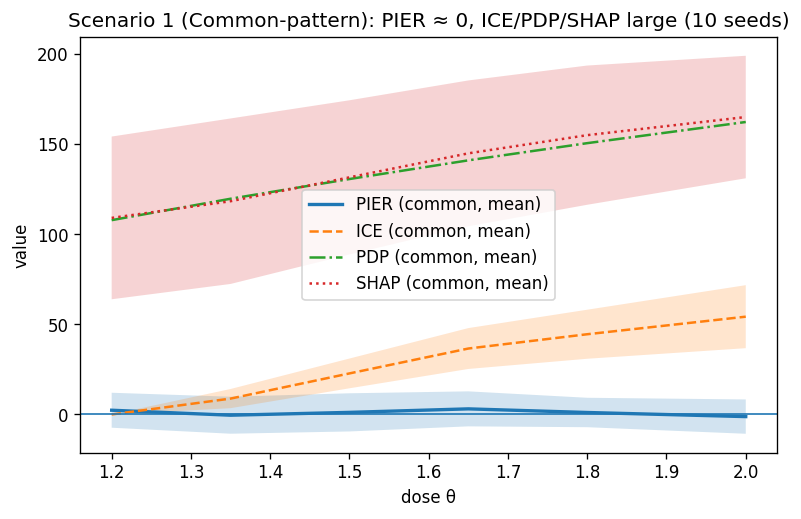

In [35]:
mean_pier_common, lo_pier_common, hi_pier_common = mean_and_ci(common_pier)
mean_ice_common,  lo_ice_common,  hi_ice_common  = mean_and_ci(common_ice)
mean_pdp_common,  lo_pdp_common,  hi_pdp_common  = mean_and_ci(common_pdp)
mean_shap_common, lo_shap_common, hi_shap_common = mean_and_ci(common_shap)

fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.5))

ax.plot(theta_grid, mean_pier_common, label="PIER (common, mean)", linewidth=2)
ax.fill_between(theta_grid, lo_pier_common, hi_pier_common, alpha=0.2, linewidth=0)

ax.plot(theta_grid, mean_ice_common,  label="ICE (common, mean)",  linestyle="--")
ax.fill_between(theta_grid, lo_ice_common, hi_ice_common, alpha=0.2, linewidth=0)

ax.plot(theta_grid, mean_pdp_common,  label="PDP (common, mean)",  linestyle="-.")
ax.fill_between(theta_grid, lo_pdp_common, hi_pdp_common, alpha=0.2, linewidth=0)

ax.plot(theta_grid, mean_shap_common, label="SHAP (common, mean)", linestyle=":")
ax.fill_between(theta_grid, lo_shap_common, hi_shap_common, alpha=0.2, linewidth=0)


ax.axhline(0.0, linewidth=1.0)
ax.set_xlabel("dose θ")
ax.set_ylabel("value")
ax.set_title("Scenario 1 (Common-pattern): PIER ≈ 0, ICE/PDP/SHAP large (10 seeds)")
ax.legend()
plt.show()


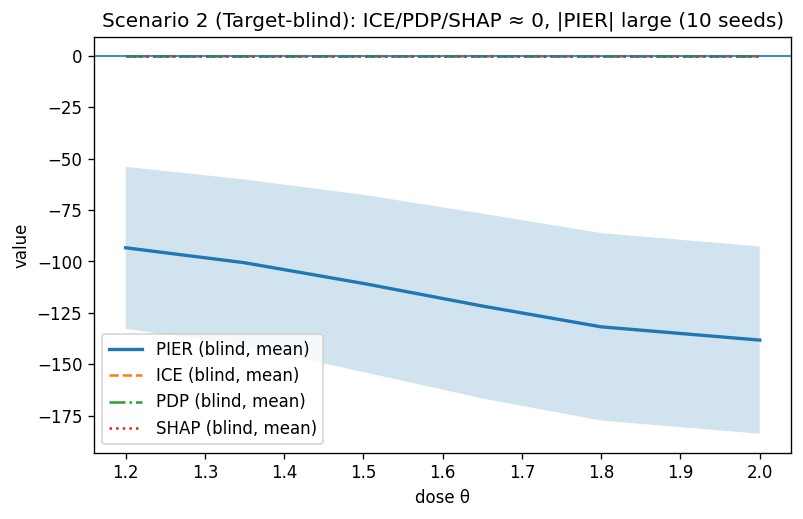

In [36]:
mean_pier_blind, lo_pier_blind, hi_pier_blind = mean_and_ci(blind_pier)
mean_ice_blind,  lo_ice_blind,  hi_ice_blind  = mean_and_ci(blind_ice)
mean_pdp_blind,  lo_pdp_blind,  hi_pdp_blind  = mean_and_ci(blind_pdp)
mean_shap_blind, lo_shap_blind, hi_shap_blind = mean_and_ci(blind_shap)

fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.5))

ax.plot(theta_grid, mean_pier_blind, label="PIER (blind, mean)", linewidth=2)
ax.fill_between(theta_grid, lo_pier_blind, hi_pier_blind, alpha=0.2, linewidth=0)

ax.plot(theta_grid, mean_ice_blind,  label="ICE (blind, mean)",  linestyle="--")
ax.fill_between(theta_grid, lo_ice_blind, hi_ice_blind, alpha=0.2, linewidth=0)

ax.plot(theta_grid, mean_pdp_blind,  label="PDP (blind, mean)",  linestyle="-.")
ax.fill_between(theta_grid, lo_pdp_blind, hi_pdp_blind, alpha=0.2, linewidth=0)

ax.plot(theta_grid, mean_shap_blind, label="SHAP (blind, mean)", linestyle=":")
ax.fill_between(theta_grid, lo_shap_blind, hi_shap_blind, alpha=0.2, linewidth=0)

ax.axhline(0.0, linewidth=1.0)
ax.set_xlabel("dose θ")
ax.set_ylabel("value")
ax.set_title("Scenario 2 (Target-blind): ICE/PDP/SHAP ≈ 0, |PIER| large (10 seeds)")
ax.legend()
plt.show()
